# Phase 2 — MobileNetV2
### Waste Classification System — TACO Dataset

> **Dataset reference:**
> Proença, P. F., & Simões, P. (2020). TACO: Trash Annotations in Context
> for Litter Detection. arXiv preprint arXiv:2003.06975.

---

**What this notebook does:**
1. Load preprocessed dataset from Google Drive
2. Build MobileNetV2 architecture from scratch in PyTorch
3. Train with class-weighted loss + WeightedRandomSampler
4. Early stopping (patience = 5)
5. Plot training curves
6. Evaluate on test set

**Model:** MobileNetV2
**Classes:** Recyclable (0) / Non-Recyclable (1)
**Input:** 224 × 224 × 3
**Epochs:** 20 (early stopping patience=5)

In [ ]:
import os
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print('Imports successful.')

Device : cpu
Imports successful.


In [ ]:
# Paths
PKL_PATH     = '/content/drive/MyDrive/waste_classification/taco_preprocessed_balanced.pkl'
MODEL_SAVE   = '/content/drive/MyDrive/waste_classification/mobilenetv2_best.pth'
RESULTS_SAVE = '/content/drive/MyDrive/waste_classification/mobilenetv2_results.pkl'

# Training
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 0.001
PATIENCE      = 5

# Model
IMAGE_SIZE  = 224
NUM_CLASSES = 2
CLASS_NAMES = ['Recyclable', 'Non-Recyclable']

print('Configuration set.')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Epochs        : {EPOCHS} (early stop patience={PATIENCE})')
print(f'  Learning rate : {LEARNING_RATE}')

Configuration set.
  Batch size    : 32
  Epochs        : 30 (early stop patience=5)
  Learning rate : 0.001


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']       # (1400, 224, 224, 3) float32
y_train       = data['y_train']       # (1400,) int64
X_val         = data['X_val']         # (300, 224, 224, 3) float32
y_val         = data['y_val']         # (300,) int64
X_test        = data['X_test']        # (300, 224, 224, 3) float32
y_test        = data['y_test']        # (300,) int64
class_weights = data['class_weights']

print('Dataset loaded.')
print(f'  Train : {X_train.shape}')
print(f'  Val   : {X_val.shape}')
print(f'  Test  : {X_test.shape}')
print(f'  Pixel range : [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'  Class weights : {class_weights}')

Mounted at /content/drive
Dataset loaded.
  Train : (1400, 224, 224, 3)
  Val   : (300, 224, 224, 3)
  Test  : (300, 224, 224, 3)
  Pixel range : [0.00, 1.00]
  Class weights : [1. 1.]


In [ ]:
class WasteDataset(Dataset):
    """
    Loads images from numpy arrays (H,W,3) normalized [0,1].
    Converts to PIL then applies transforms.
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = self.images[idx]
        label = int(self.labels[idx])
        img_pil = Image.fromarray((img * 255).astype(np.uint8))
        if self.transform:
            img = self.transform(img_pil)
        else:
            img = transforms.ToTensor()(img_pil)
        return img, label


# Transforms
# Training: extra augmentation on top of Phase 1 augmentation
# Val/Test: only normalize — no augmentation (fair evaluation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = WasteDataset(X_train, y_train, transform=train_transform)
val_dataset   = WasteDataset(X_val,   y_val,   transform=val_test_transform)
test_dataset  = WasteDataset(X_test,  y_test,  transform=val_test_transform)

# WeightedRandomSampler — balanced batches during training
sample_weights = [class_weights[int(l)] for l in y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print('DataLoaders ready.')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

imgs, lbls = next(iter(train_loader))
print(f'  Batch shape   : {imgs.shape}')   # (32, 3, 224, 224)
print(f'  Label dist    : {Counter(lbls.numpy().tolist())}')

DataLoaders ready.
  Train batches : 44
  Val batches   : 10
  Test batches  : 10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Batch shape   : torch.Size([32, 3, 224, 224])
  Label dist    : Counter({1: 16, 0: 16})


In [ ]:
class InvertedResidualBlock(nn.Module):
    """
    MobileNetV2 Inverted Residual Block.

    Structure:
      Expand  → 1×1 conv: in_ch → in_ch * t        [ReLU6]
      Dwise   → 3×3 dw conv: expanded → expanded   [ReLU6]
      Project → 1×1 conv: expanded → out_ch         [Linear]

    Skip connection: only when stride=1 AND in_ch == out_ch

    Args:
      in_channels  : number of input channels
      out_channels : number of output channels
      stride       : 1 = same size, 2 = halve spatial dims
      expand_ratio : channel expansion factor t
    """
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super(InvertedResidualBlock, self).__init__()

        self.use_skip   = (stride == 1 and in_channels == out_channels)
        hidden_channels = in_channels * expand_ratio
        layers = []

        # Expand (skip if t=1 — no expansion needed for first block)
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_channels, hidden_channels,
                          kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_channels),
                nn.ReLU6(inplace=True)
            ]

        # Depthwise conv (groups=hidden_channels = one filter per channel)
        layers += [
            nn.Conv2d(hidden_channels, hidden_channels,
                      kernel_size=3, stride=stride, padding=1,
                      groups=hidden_channels, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU6(inplace=True)
        ]

        # Project — linear bottleneck (no activation)
        layers += [
            nn.Conv2d(hidden_channels, out_channels,
                      kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
            # No ReLU6 here — this is the linear bottleneck
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_skip:
            return x + self.block(x)   # residual addition
        return self.block(x)


class MobileNetV2(nn.Module):
    """
    MobileNetV2 built from scratch.
    Reference: Sandler et al., 2018.

    Architecture (t=expand, c=out_channels, n=blocks, s=stride):
      Stem conv:  3 → 32,  stride 2   → 112x112
      t=1 c=16  n=1 s=1             → 112x112
      t=6 c=24  n=2 s=2             →  56x56
      t=6 c=32  n=3 s=2             →  28x28
      t=6 c=64  n=4 s=2             →  14x14
      t=6 c=96  n=3 s=1             →  14x14
      t=6 c=160 n=3 s=2             →   7x7
      t=6 c=320 n=1 s=1             →   7x7
      Conv 1x1: 320 → 1280          →   7x7
      Global avg pool               →   1x1
      Linear: 1280 → num_classes
    """
    def __init__(self, num_classes=2):
        super(MobileNetV2, self).__init__()

        # Inverted residual config: (expand_ratio, out_ch, num_blocks, stride)
        config = [
            (1,  16,  1, 1),
            (6,  24,  2, 2),
            (6,  32,  3, 2),
            (6,  64,  4, 2),
            (6,  96,  3, 1),
            (6, 160,  3, 2),
            (6, 320,  1, 1),
        ]

        # Stem: 224x224x3 → 112x112x32
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        # Inverted residual blocks
        layers      = []
        in_channels = 32

        for t, c, n, s in config:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidualBlock(in_channels, c, stride, t))
                in_channels = c

        self.features = nn.Sequential(*layers)

        # Final conv: 7x7x320 → 7x7x1280
        self.final_conv = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            nn.ReLU6(inplace=True)
        )

        # Global average pool: 7x7x1280 → 1280-dim vector
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(1280, num_classes)
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.stem(x)             # 224x224 → 112x112
        x = self.features(x)         # 112x112 → 7x7
        x = self.final_conv(x)       # 7x7x320 → 7x7x1280
        x = self.global_avg_pool(x)  # 7x7 → 1x1
        x = x.view(x.size(0), -1)   # flatten → (batch, 1280)
        x = self.classifier(x)       # → (batch, num_classes)
        return x

    def _initialize_weights(self):
        """
        Kaiming (He) initialization.
        Designed for ReLU networks — prevents vanishing/exploding gradients
        when training from scratch.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)


# Instantiate
model = MobileNetV2(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)

print('MobileNetV2 built from scratch.')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')

# Verify with dummy forward pass
dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'  Output shape         : {out.shape}')   # (1, 2)

MobileNetV2 built from scratch.
  Total parameters     : 2,226,434
  Trainable parameters : 2,226,434
  Output shape         : torch.Size([1, 2])


In [ ]:
# Class-weighted loss — penalizes mistakes on minority class more
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer — adaptive learning rate, good for training from scratch
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau — halves LR if val_loss stalls for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('Loss      : CrossEntropyLoss (class weighted)')
print('Optimizer : Adam')
print('Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)')

Loss      : CrossEntropyLoss (class weighted)
Optimizer : Adam
Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """One full training epoch. Returns avg loss and accuracy."""
    model.train()    # enables dropout + batchnorm training mode
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on val or test set. Returns loss, acc, preds, labels."""
    model.eval()     # disables dropout + freezes batchnorm
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels


print('Training and evaluation functions ready.')

Training and evaluation functions ready.


In [ ]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_loss    = float('inf')
patience_counter = 0
best_epoch       = 0

print(f'Training MobileNetV2 for up to {EPOCHS} epochs...')
print('=' * 68)
print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc":>10} '
      f'{"Val Loss":>10} {"Val Acc":>10}  Status')
print('=' * 68)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device)

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        status = '✅ best saved'
    else:
        patience_counter += 1
        status = f'patience {patience_counter}/{PATIENCE}'

    print(f'{epoch:>6} {train_loss:>12.4f} {train_acc:>9.4f} '
          f'{val_loss:>10.4f} {val_acc:>9.4f}  {status}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print('=' * 68)
print(f'Best epoch : {best_epoch}  |  Best val loss : {best_val_loss:.4f}')
print(f'Model saved to: {MODEL_SAVE}')

Training MobileNetV2 for up to 30 epochs...
 Epoch   Train Loss  Train Acc   Val Loss    Val Acc  Status
     1       0.7283    0.5079     0.9740    0.5000  ✅ best saved
     2       0.7071    0.5407     0.7340    0.5000  ✅ best saved
     3       0.6956    0.5636     0.7784    0.6000  patience 1/5
     4       0.6108    0.6979     0.7393    0.6467  patience 2/5
     5       0.5582    0.7250     0.5690    0.7433  ✅ best saved
     6       0.5083    0.7736     0.6157    0.7700  patience 1/5
     7       0.5256    0.7493     0.4422    0.8067  ✅ best saved
     8       0.4287    0.8093     0.3545    0.8633  ✅ best saved
     9       0.4465    0.8057     0.3781    0.8467  patience 1/5
    10       0.4102    0.8193     0.3250    0.8667  ✅ best saved
    11       0.4194    0.8129     0.4153    0.8167  patience 1/5
    12       0.4005    0.8293     0.3655    0.8500  patience 2/5
    13       0.3897    0.8436     0.3941    0.8233  patience 3/5
    14       0.4056    0.8193     0.4347    0.8167

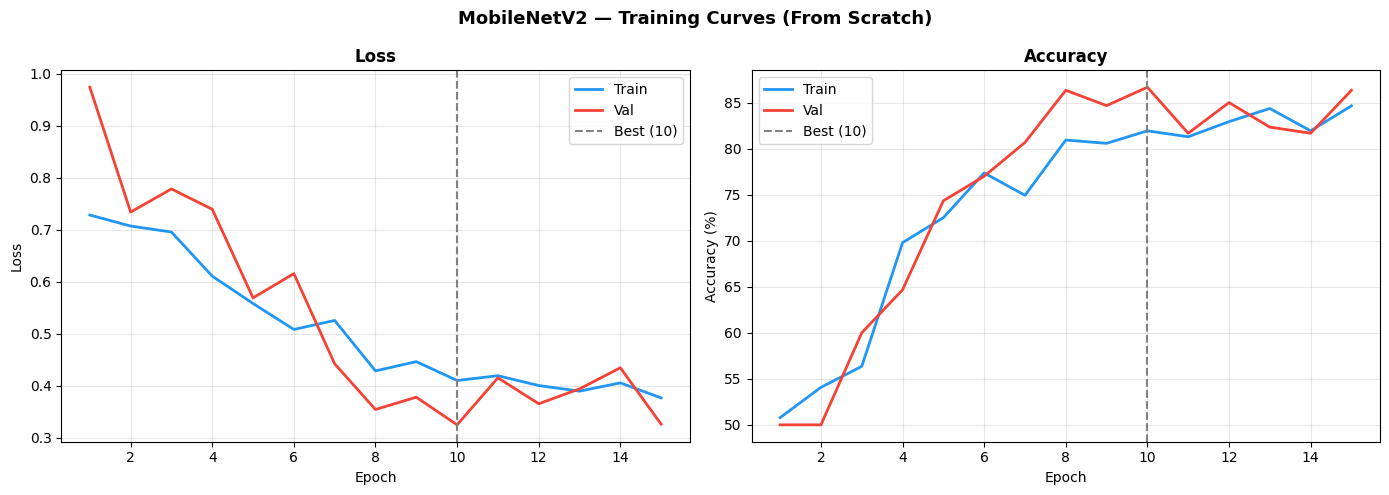

Saved: mobilenetv2_training_curves.png


In [ ]:
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(x, history['train_loss'], label='Train', color='#2196F3', lw=2)
axes[0].plot(x, history['val_loss'],   label='Val',   color='#F44336', lw=2)
axes[0].axvline(x=best_epoch, color='gray', linestyle='--',
                label=f'Best ({best_epoch})')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x, [a*100 for a in history['train_acc']],
             label='Train', color='#2196F3', lw=2)
axes[1].plot(x, [a*100 for a in history['val_acc']],
             label='Val',   color='#F44336', lw=2)
axes[1].axvline(x=best_epoch, color='gray', linestyle='--',
                label=f'Best ({best_epoch})')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 — Training Curves (From Scratch)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/mobilenetv2_training_curves.png', dpi=150)
plt.show()
print('Saved: mobilenetv2_training_curves.png')

In [ ]:
# Load best weights
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
print(f'Loaded best model from epoch {best_epoch}.')

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

f1     = f1_score(test_labels, test_preds, average='weighted')
report = classification_report(
    test_labels, test_preds, target_names=CLASS_NAMES)

print(f'\nTest Results:')
print(f'  Accuracy : {test_acc * 100:.2f}%')
print(f'  F1 Score : {f1:.4f}')
print(f'  Loss     : {test_loss:.4f}')
print(f'\nClassification Report:')
print(report)

Loaded best model from epoch 10.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Results:
  Accuracy : 85.33%
  F1 Score : 0.8529
  Loss     : 0.3920

Classification Report:
                precision    recall  f1-score   support

    Recyclable       0.90      0.80      0.85       150
Non-Recyclable       0.82      0.91      0.86       150

      accuracy                           0.85       300
     macro avg       0.86      0.85      0.85       300
  weighted avg       0.86      0.85      0.85       300



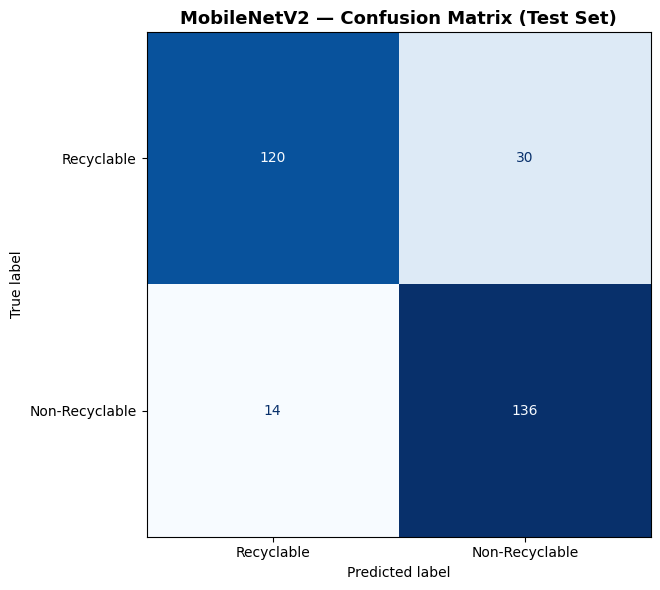

Saved: mobilenetv2_confusion_matrix.png


In [ ]:
#Test CM
cm   = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('MobileNetV2 — Confusion Matrix (Test Set)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/mobilenetv2_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: mobilenetv2_confusion_matrix.png')

In [ ]:
results = {
    # Identity
    'model_name'   : 'MobileNetV2',
    'num_classes'  : NUM_CLASSES,
    'image_size'   : IMAGE_SIZE,
    'total_params' : total_params,

    # Training config
    'epochs_ran'   : epochs_ran,
    'best_epoch'   : best_epoch,
    'batch_size'   : BATCH_SIZE,
    'learning_rate': LEARNING_RATE,

    # History
    'train_loss'   : history['train_loss'],
    'train_acc'    : history['train_acc'],
    'val_loss'     : history['val_loss'],
    'val_acc'      : history['val_acc'],

    # Test results
    'test_loss'    : test_loss,
    'test_acc'     : test_acc,
    'f1_score'     : f1,
    'conf_matrix'  : cm,
    'test_preds'   : test_preds,
    'test_labels'  : test_labels,
    'class_report' : report,
    'class_names'  : CLASS_NAMES,
}

with open(RESULTS_SAVE, 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to: {RESULTS_SAVE}')
print('\n✅ Phase 2 complete!')
print(f'\n  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  F1 Score      : {f1:.4f}')
print(f'  Best Epoch    : {best_epoch} / {epochs_ran}')
print(f'  Parameters    : {total_params:,}')

Results saved to: /content/drive/MyDrive/waste_classification/mobilenetv2_results.pkl

✅ Phase 2 complete!

  Test Accuracy : 85.33%
  F1 Score      : 0.8529
  Best Epoch    : 10 / 15
  Parameters    : 2,226,434
